In [1]:
from pathlib import Path
from shapely.geometry import box

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

DATA_DIR = Path(r"P:\HACKATHONS\SIH26PS67\DATA\REF")
COASTLINE_DIR = DATA_DIR / "coastline"
GSHHG_DIR = COASTLINE_DIR / "gshhg"   # notice the G at the end

GSHHS_DIR = GSHHG_DIR / "GSHHS_shp"   # notice the S at the end
WDBII_DIR = GSHHG_DIR / "WDBII_shp"

RESOLUTIONS = ["c", "l", "i", "h", "f"]

In [2]:
GEOGRAPHIC_RESOLUTION = "i"
GEOGRAPHIC_LEVEL = 1

geographic_path = (
    GSHHS_DIR
    / GEOGRAPHIC_RESOLUTION
    / f"GSHHS_{GEOGRAPHIC_RESOLUTION}_L{GEOGRAPHIC_LEVEL}.shp"
)

gdf_geo = gpd.read_file(geographic_path)

print(f"Dataset: {GEOGRAPHIC_RESOLUTION.upper()} / L{GEOGRAPHIC_LEVEL}")
print(f"Features: {len(gdf_geo):,}")
print(f"CRS: {gdf_geo.crs}")

Dataset: I / L1
Features: 32,830
CRS: EPSG:4326


In [3]:
minx, miny, maxx, maxy = gdf_geo.total_bounds

print(f"Minimum longitude: {minx}")
print(f"Maximum longitude: {maxx}")
print(f"Minimum latitude : {miny}")
print(f"Maximum latitude : {maxy}")

Minimum longitude: -180.0
Maximum longitude: 180.0
Minimum latitude : -68.919814
Maximum latitude : 83.633389


In [4]:
global_extent = pd.DataFrame({
    "boundary": [
        "Minimum Longitude",
        "Maximum Longitude",
        "Minimum Latitude",
        "Maximum Latitude",
    ],
    "value": [
        minx,
        maxx,
        miny,
        maxy,
    ]
})

global_extent

,boundary,value
0,Minimum Longitude,-180.000000
1,Maximum Longitude,180.000000
2,Minimum Latitude,-68.919814
3,Maximum Latitude,83.633389


In [5]:
bounds = gdf_geo.geometry.bounds

gdf_geo["min_lon"] = bounds["minx"]
gdf_geo["min_lat"] = bounds["miny"]
gdf_geo["max_lon"] = bounds["maxx"]
gdf_geo["max_lat"] = bounds["maxy"]

gdf_geo["lon_span_deg"] = (
    gdf_geo["max_lon"] - gdf_geo["min_lon"]
)

gdf_geo["lat_span_deg"] = (
    gdf_geo["max_lat"] - gdf_geo["min_lat"]
)

gdf_geo[
    [
        "id",
        "min_lon",
        "max_lon",
        "min_lat",
        "max_lat",
        "lon_span_deg",
        "lat_span_deg",
    ]
].head()

,id,min_lon,max_lon,min_lat,max_lat,lon_span_deg,lat_span_deg
0,0-E,-9.500389,180.000000,1.269500,77.719583,189.500389,76.450083
1,0-W,-180.000000,-169.640889,64.239583,68.993778,10.359111,4.754195
2,1,-17.533778,51.415417,-34.830444,37.349556,68.949195,72.180000
3,2,-168.132417,-55.620806,7.204806,72.002139,112.511611,64.797333
4,3,-81.328778,-34.793778,-53.900444,12.464500,46.535000,66.364944


In [6]:
gdf_geo["lon_span_deg"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    32830.000000
mean         0.091211
std          1.431274
min          0.000500
50%          0.024194
75%          0.049945
90%          0.115000
95%          0.210000
99%          0.774755
max        189.500389
Name: lon_span_deg, dtype: float64

In [7]:
gdf_geo["lat_span_deg"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    32830.000000
mean         0.051087
std          0.832303
min          0.000195
50%          0.013305
75%          0.028750
90%          0.067527
95%          0.122460
99%          0.422400
max         76.450083
Name: lat_span_deg, dtype: float64

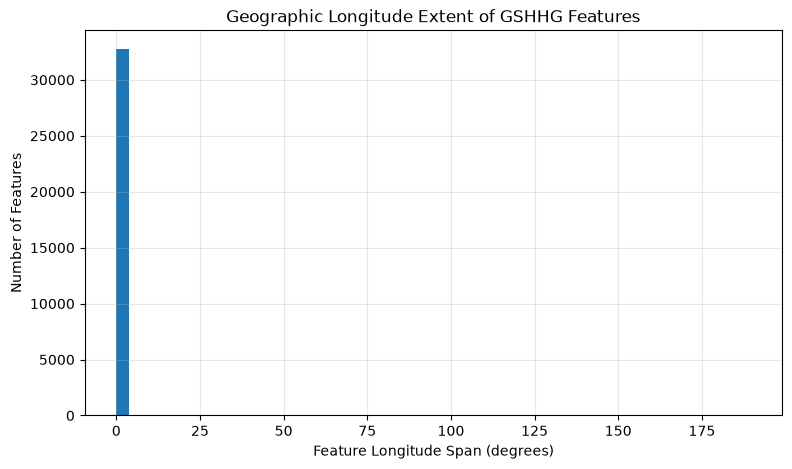

In [8]:
plt.figure(figsize=(9, 5))

plt.hist(
    gdf_geo["lon_span_deg"],
    bins=50
)

plt.xlabel("Feature Longitude Span (degrees)")
plt.ylabel("Number of Features")
plt.title("Geographic Longitude Extent of GSHHG Features")

plt.grid(True, alpha=0.3)

plt.show()

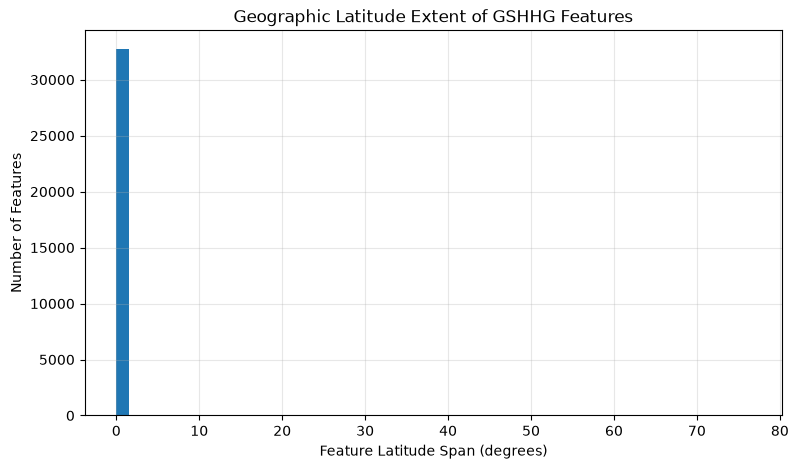

In [9]:
plt.figure(figsize=(9, 5))

plt.hist(
    gdf_geo["lat_span_deg"],
    bins=50
)

plt.xlabel("Feature Latitude Span (degrees)")
plt.ylabel("Number of Features")
plt.title("Geographic Latitude Extent of GSHHG Features")

plt.grid(True, alpha=0.3)

plt.show()

In [10]:
centroids = gdf_geo.geometry.centroid

gdf_geo["centroid_lon"] = centroids.x
gdf_geo["centroid_lat"] = centroids.y

gdf_geo[
    [
        "id",
        "centroid_lon",
        "centroid_lat"
    ]
].head()

C:\Users\devesh\AppData\Local\Temp\ipykernel_10436\521291291.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_geo.geometry.centroid


,id,centroid_lon,centroid_lat
0,0-E,81.856257,48.453543
1,0-W,-175.842739,66.480221
2,1,17.668179,6.901243
3,2,-105.960833,49.586278
4,3,-60.734180,-14.779290


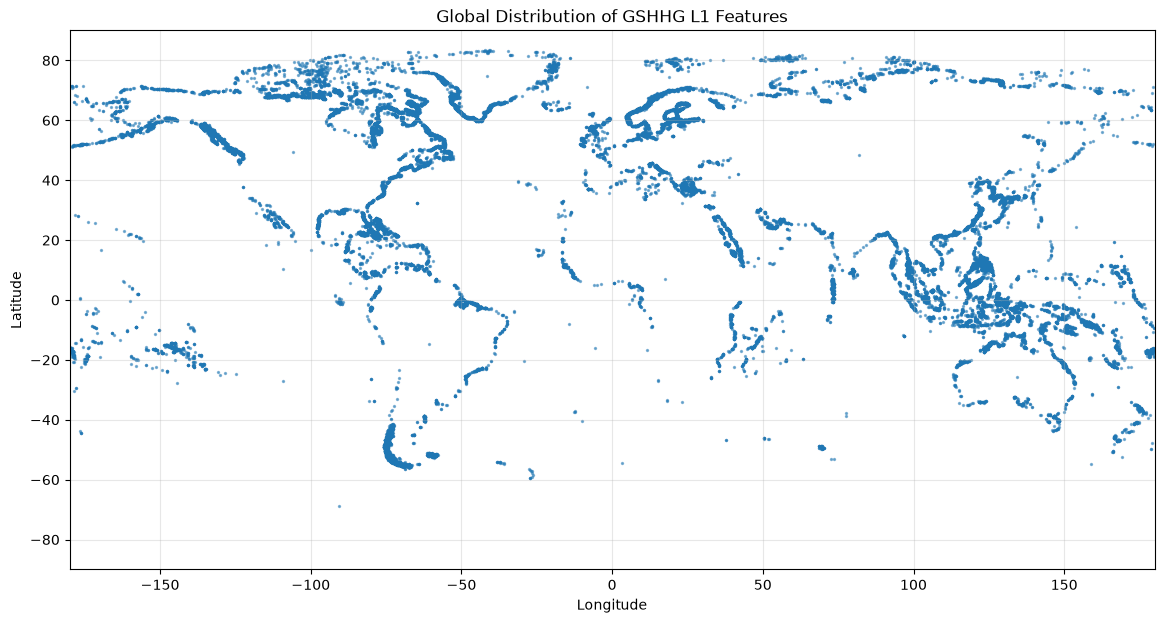

In [11]:
plt.figure(figsize=(14, 7))

plt.scatter(
    gdf_geo["centroid_lon"],
    gdf_geo["centroid_lat"],
    s=2,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global Distribution of GSHHG L1 Features")

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.grid(True, alpha=0.3)

plt.show()

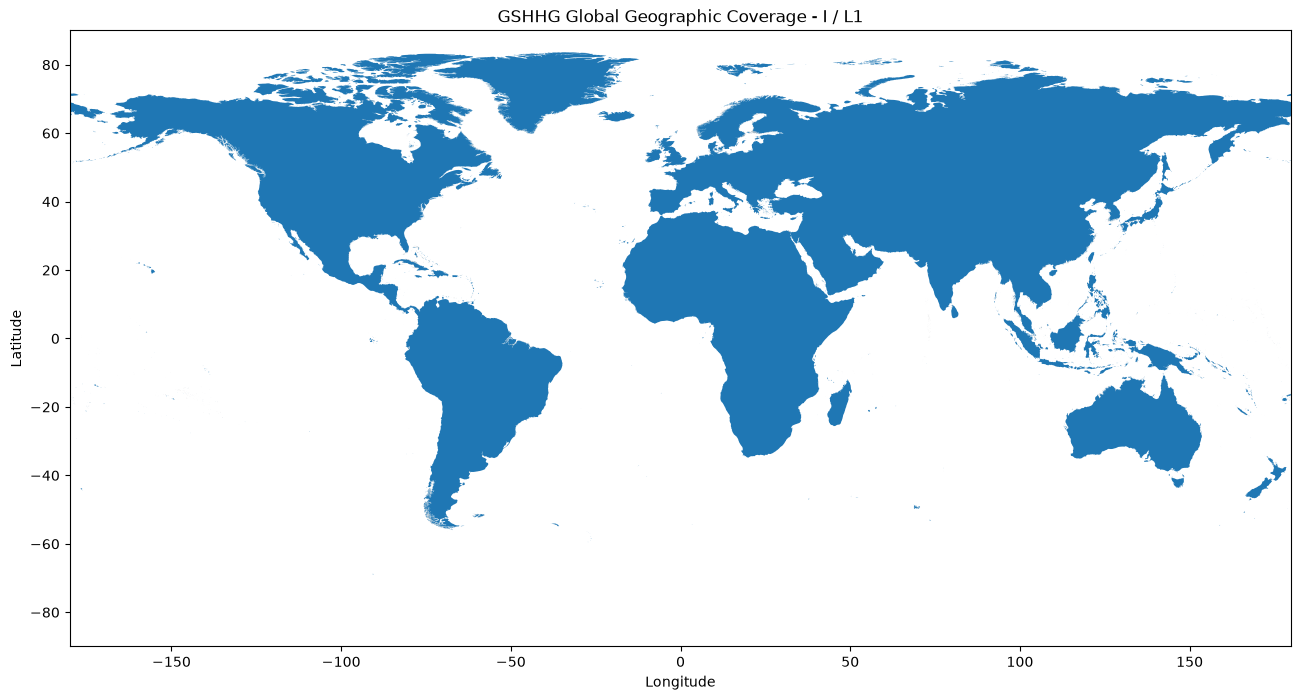

In [12]:
fig, ax = plt.subplots(figsize=(16, 8))

gdf_geo.plot(
    ax=ax,
    linewidth=0.2
)

ax.set_title(
    "GSHHG Global Geographic Coverage - "
    f"{GEOGRAPHIC_RESOLUTION.upper()} / L{GEOGRAPHIC_LEVEL}"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

plt.show()

In [13]:
lat_bins = np.arange(-90, 91, 10)

lat_labels = [
    f"{lat_bins[i]} to {lat_bins[i+1]}"
    for i in range(len(lat_bins) - 1)
]

gdf_geo["latitude_band"] = pd.cut(
    gdf_geo["centroid_lat"],
    bins=lat_bins,
    labels=lat_labels,
    include_lowest=True
)

latitude_distribution = (
    gdf_geo["latitude_band"]
    .value_counts()
    .sort_index()
)

latitude_distribution

latitude_band
-90 to -80       0
-80 to -70       0
-70 to -60       1
-60 to -50    1286
-50 to -40     934
-40 to -30     377
-30 to -20     636
-20 to -10    1628
-10 to 0      2956
0 to 10       2480
10 to 20      2174
20 to 30      3547
30 to 40      1975
40 to 50      1337
50 to 60      4006
60 to 70      6780
70 to 80      2472
80 to 90       241
Name: count, dtype: int64

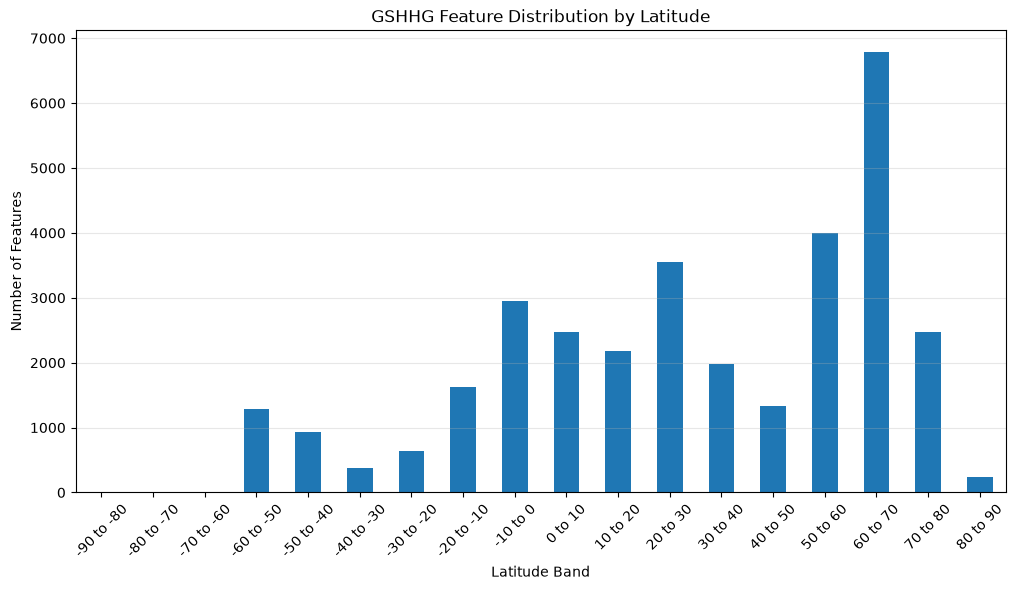

In [14]:
plt.figure(figsize=(12, 6))

latitude_distribution.plot(
    kind="bar"
)

plt.xlabel("Latitude Band")
plt.ylabel("Number of Features")
plt.title("GSHHG Feature Distribution by Latitude")

plt.xticks(rotation=45)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [15]:
latitude_percentage = (
    latitude_distribution
    / latitude_distribution.sum()
    * 100
)

latitude_percentage

latitude_band
-90 to -80     0.000000
-80 to -70     0.000000
-70 to -60     0.003046
-60 to -50     3.917149
-50 to -40     2.844959
-40 to -30     1.148340
-30 to -20     1.937253
-20 to -10     4.958879
-10 to 0       9.003960
0 to 10        7.554066
10 to 20       6.621992
20 to 30      10.804143
30 to 40       6.015839
40 to 50       4.072495
50 to 60      12.202254
60 to 70      20.651843
70 to 80       7.529698
80 to 90       0.734085
Name: count, dtype: float64

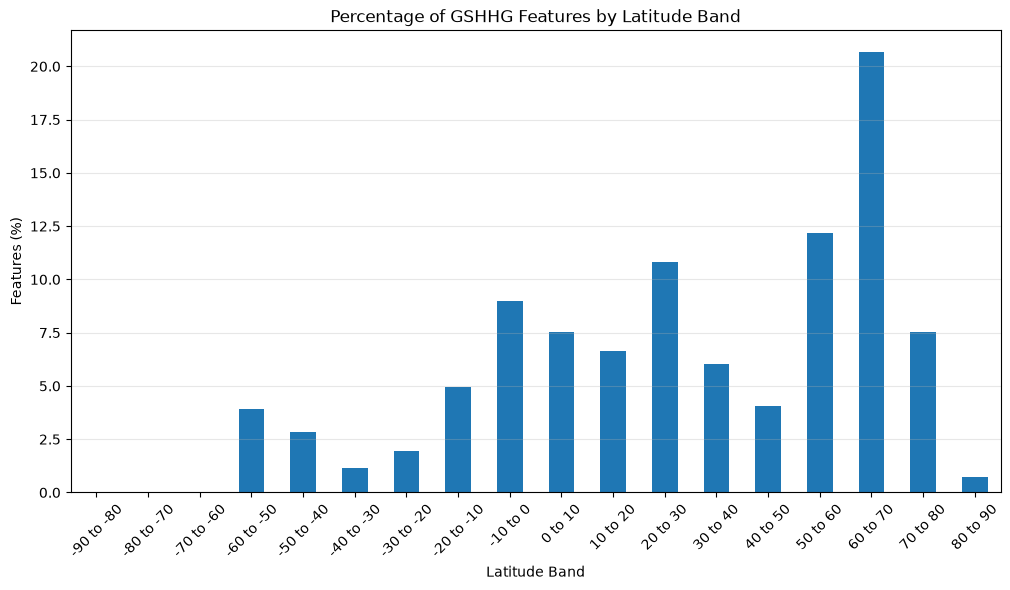

In [16]:
plt.figure(figsize=(12, 6))

latitude_percentage.plot(
    kind="bar"
)

plt.xlabel("Latitude Band")
plt.ylabel("Features (%)")
plt.title("Percentage of GSHHG Features by Latitude Band")

plt.xticks(rotation=45)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [17]:
lon_bins = np.arange(-180, 181, 10)

lon_labels = [
    f"{lon_bins[i]} to {lon_bins[i+1]}"
    for i in range(len(lon_bins) - 1)
]

gdf_geo["longitude_band"] = pd.cut(
    gdf_geo["centroid_lon"],
    bins=lon_bins,
    labels=lon_labels,
    include_lowest=True
)

longitude_distribution = (
    gdf_geo["longitude_band"]
    .value_counts()
    .sort_index()
)

longitude_distribution

longitude_band
-180 to -170     245
-170 to -160     237
-160 to -150     280
-150 to -140     383
-140 to -130     726
-130 to -120     513
-120 to -110     391
-110 to -100     548
-100 to -90     1064
-90 to -80      1412
-80 to -70      4006
-70 to -60      2152
-60 to -50      1714
-50 to -40       918
-40 to -30       211
-30 to -20       238
-20 to -10       347
-10 to 0         432
0 to 10          884
10 to 20        1783
20 to 30        1769
30 to 40         723
40 to 50         576
50 to 60         484
60 to 70         180
70 to 80         441
80 to 90         229
90 to 100        996
100 to 110      1118
110 to 120      1094
120 to 130      3149
130 to 140      1200
140 to 150       701
150 to 160       797
160 to 170       503
170 to 180       386
Name: count, dtype: int64

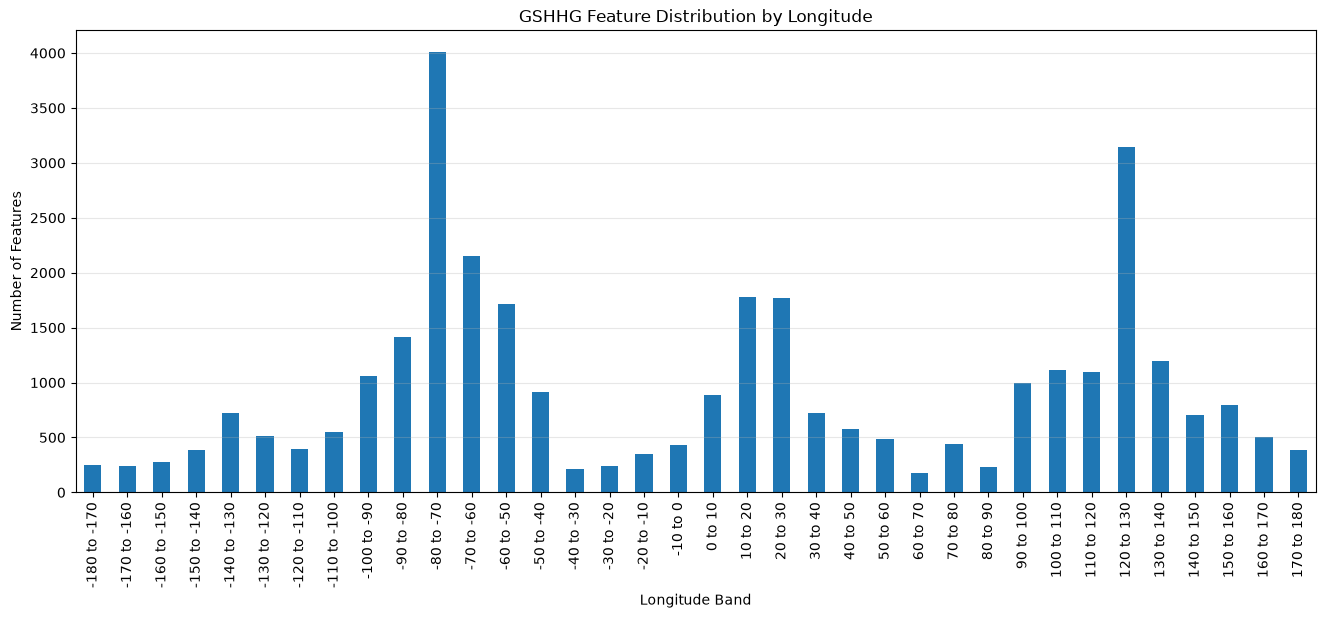

In [18]:
plt.figure(figsize=(16, 6))

longitude_distribution.plot(
    kind="bar"
)

plt.xlabel("Longitude Band")
plt.ylabel("Number of Features")
plt.title("GSHHG Feature Distribution by Longitude")

plt.xticks(rotation=90)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [19]:
lat_bins = np.arange(-90, 91, 10)
lon_bins = np.arange(-180, 181, 10)

gdf_geo["lat_bin"] = pd.cut(
    gdf_geo["centroid_lat"],
    bins=lat_bins,
    include_lowest=True
)

gdf_geo["lon_bin"] = pd.cut(
    gdf_geo["centroid_lon"],
    bins=lon_bins,
    include_lowest=True
)

geographic_density = pd.crosstab(
    gdf_geo["lat_bin"],
    gdf_geo["lon_bin"]
)

geographic_density.shape

(16, 36)

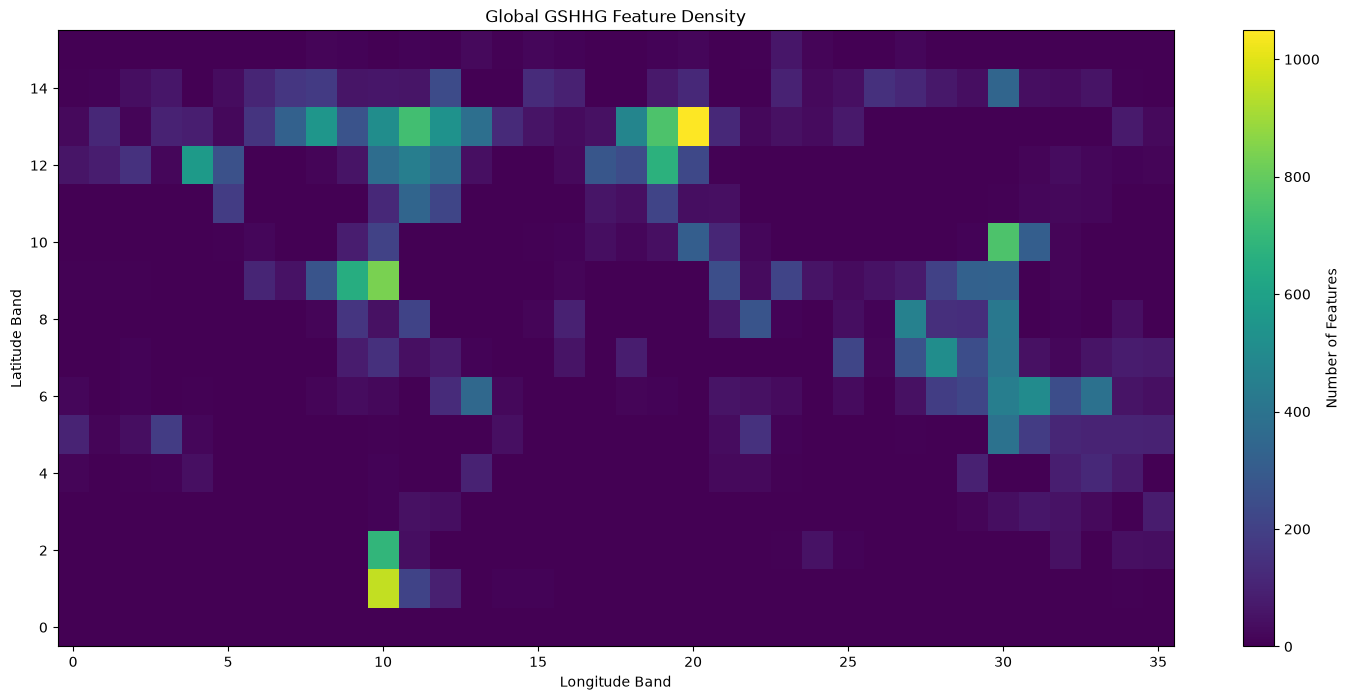

In [20]:
plt.figure(figsize=(18, 8))

plt.imshow(
    geographic_density,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Number of Features"
)

plt.xlabel("Longitude Band")
plt.ylabel("Latitude Band")
plt.title("Global GSHHG Feature Density")

plt.show()

In [23]:
def count_ring_vertices(ring):
    return len(ring.coords)


def count_polygon_vertices(polygon):
    count = count_ring_vertices(polygon.exterior)

    for interior in polygon.interiors:
        count += count_ring_vertices(interior)

    return count


def count_geometry_vertices(geometry):
    if geometry is None or geometry.is_empty:
        return 0

    geometry_type = geometry.geom_type

    if geometry_type == "Polygon":
        return count_polygon_vertices(geometry)

    if geometry_type == "MultiPolygon":
        return sum(
            count_polygon_vertices(polygon)
            for polygon in geometry.geoms
        )

    if hasattr(geometry, "geoms"):
        return sum(
            count_geometry_vertices(part)
            for part in geometry.geoms
        )

    if hasattr(geometry, "coords"):
        return len(geometry.coords)

    return 0

In [24]:
if "vertex_count" not in gdf_geo.columns:
    gdf_geo["vertex_count"] = gdf_geo.geometry.apply(
        count_geometry_vertices
    )

In [25]:
latitude_complexity = (
    gdf_geo
    .groupby("latitude_band", observed=True)
    .agg(
        features=("id", "count"),
        total_vertices=("vertex_count", "sum"),
        mean_vertices=("vertex_count", "mean"),
        median_vertices=("vertex_count", "median"),
    )
    .reset_index()
)

latitude_complexity

,latitude_band,features,total_vertices,mean_vertices,median_vertices
0,-70 to -60,1,8,8.000000,8.0
1,-60 to -50,1286,11690,9.090202,4.0
2,-50 to -40,934,9452,10.119914,5.0
3,-40 to -30,377,3154,8.366048,4.0
4,-30 to -20,636,10849,17.058176,4.0
5,-20 to -10,1628,21651,13.299140,4.0
6,-10 to 0,2956,27508,9.305819,4.0
7,0 to 10,2480,24021,9.685887,4.0
8,10 to 20,2174,15931,7.327967,4.0
9,20 to 30,3547,21227,5.984494,4.0


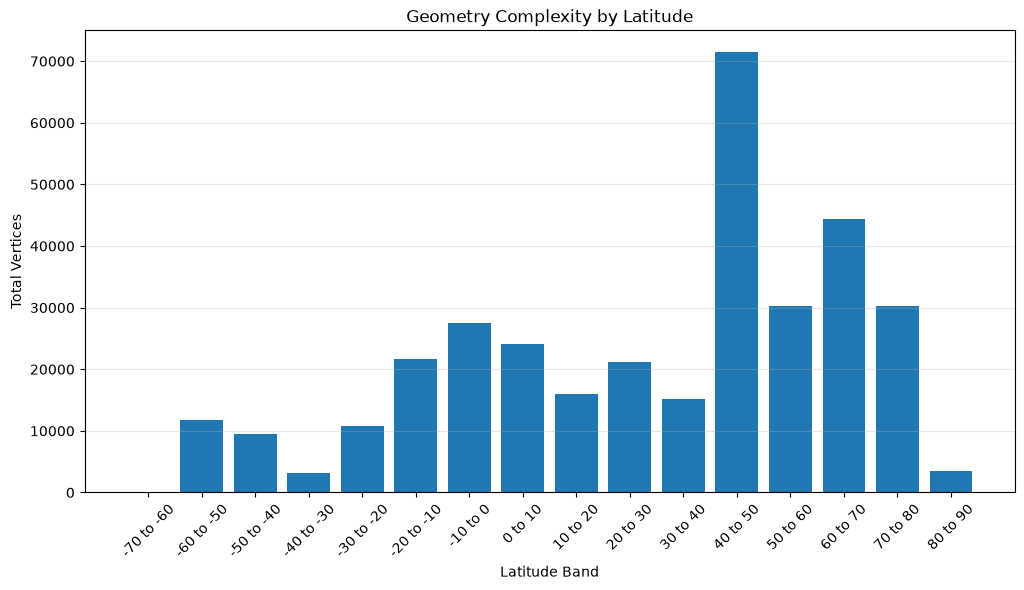

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    latitude_complexity["latitude_band"].astype(str),
    latitude_complexity["total_vertices"]
)

plt.xlabel("Latitude Band")
plt.ylabel("Total Vertices")
plt.title("Geometry Complexity by Latitude")

plt.xticks(rotation=45)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

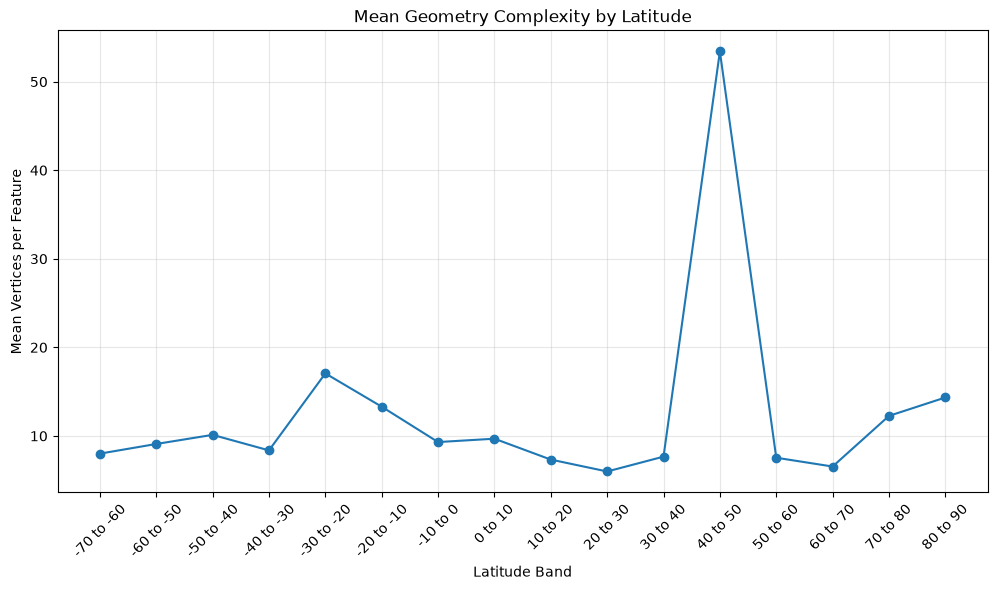

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    latitude_complexity["latitude_band"].astype(str),
    latitude_complexity["mean_vertices"],
    marker="o"
)

plt.xlabel("Latitude Band")
plt.ylabel("Mean Vertices per Feature")
plt.title("Mean Geometry Complexity by Latitude")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.show()

In [28]:
gdf_geo["area"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.999
    ]
)

count    3.283000e+04
mean     5.655758e+03
std      4.538652e+05
min      1.145774e-01
50%      1.562313e+00
75%      5.169237e+00
90%      2.456647e+01
95%      8.005001e+01
99%      8.708127e+02
99.9%    4.877274e+04
max      5.065405e+07
Name: area, dtype: float64

In [29]:
largest_features = (
    gdf_geo[
        [
            "id",
            "level",
            "area",
            "vertex_count",
            "centroid_lon",
            "centroid_lat"
        ]
    ]
    .sort_values(
        "area",
        ascending=False
    )
    .head(20)
)

largest_features

,id,level,area,vertex_count,centroid_lon,centroid_lat
0,0-E,1,5.065405e+07,34332,81.856257,48.453543
1,0-W,1,5.065405e+07,503,-175.842739,66.480221
2,1,1,2.922097e+07,6675,17.668179,6.901243
3,2,1,2.015474e+07,25378,-105.960833,49.586278
4,3,1,1.753416e+07,9904,-60.734180,-14.779290
5,6,1,7.592692e+06,6844,134.352703,-25.576498
6,7,1,2.113828e+06,7279,-41.519285,74.745352
7,8,1,7.800249e+05,2529,140.924911,-5.337254
8,9,1,7.325867e+05,1659,114.199613,0.860984
9,10,1,5.907297e+05,1384,46.698715,-19.383179


In [30]:
smallest_features = (
    gdf_geo[
        [
            "id",
            "level",
            "area",
            "vertex_count",
            "centroid_lon",
            "centroid_lat"
        ]
    ]
    .sort_values(
        "area",
        ascending=True
    )
    .head(20)
)

smallest_features

,id,level,area,vertex_count,centroid_lon,centroid_lat
32829,33252,1,0.114577,4,17.230786,40.439868
32828,33251,1,0.116193,4,148.033065,-5.909324
32827,33250,1,0.132391,4,-77.340713,65.176481
32826,33249,1,0.141275,4,134.271806,7.084694
32825,33248,1,0.145404,4,-77.803056,27.029639
32824,33247,1,0.156261,4,130.593324,-0.663509
32823,33246,1,0.156679,4,-80.795407,51.882769
32822,33245,1,0.158300,4,-89.340389,64.017463
32821,33244,1,0.159195,4,21.659954,63.249009
32820,33243,1,0.160984,4,-80.738028,51.834454


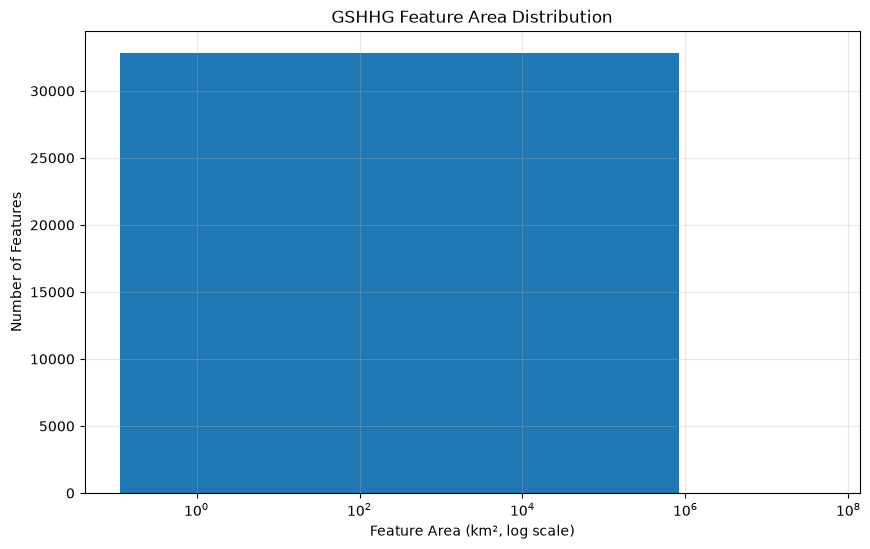

In [31]:
positive_area = gdf_geo.loc[
    gdf_geo["area"] > 0,
    "area"
]

plt.figure(figsize=(10, 6))

plt.hist(
    positive_area,
    bins=60
)

plt.xscale("log")

plt.xlabel("Feature Area (km², log scale)")
plt.ylabel("Number of Features")
plt.title("GSHHG Feature Area Distribution")

plt.grid(True, alpha=0.3)

plt.show()

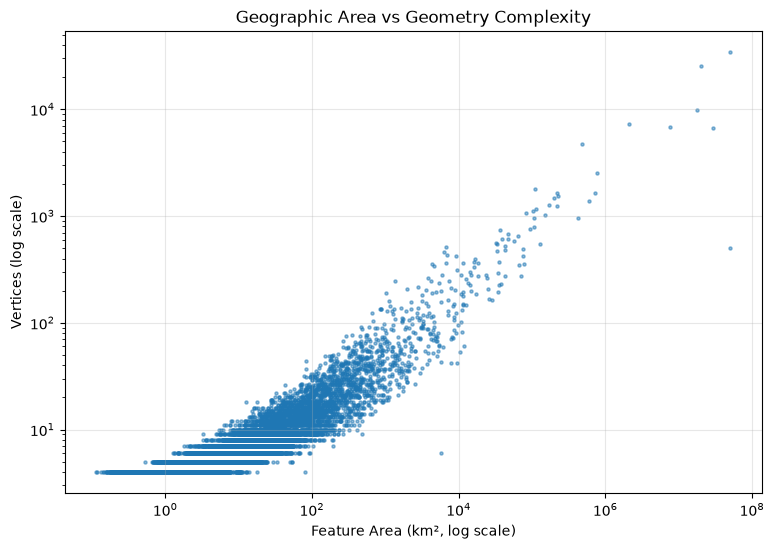

In [32]:
plt.figure(figsize=(9, 6))

plt.scatter(
    gdf_geo["area"],
    gdf_geo["vertex_count"],
    s=5,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Feature Area (km², log scale)")
plt.ylabel("Vertices (log scale)")
plt.title("Geographic Area vs Geometry Complexity")

plt.grid(True, alpha=0.3)

plt.show()

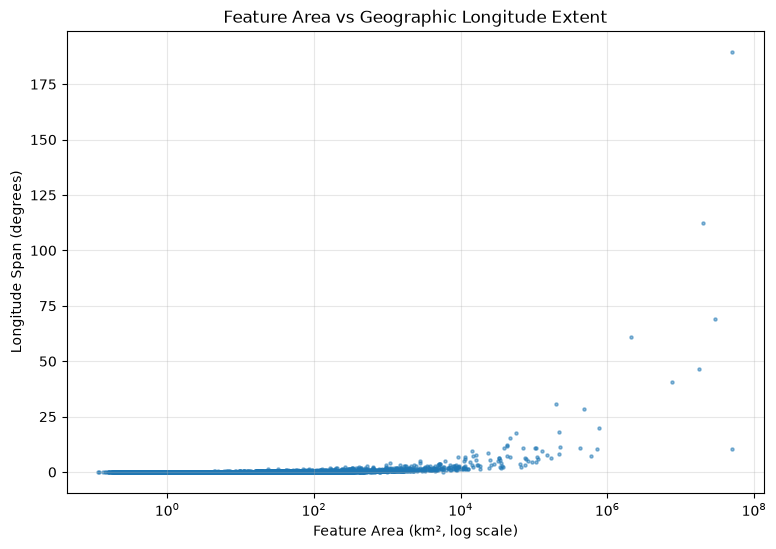

In [33]:
plt.figure(figsize=(9, 6))

plt.scatter(
    gdf_geo["area"],
    gdf_geo["lon_span_deg"],
    s=5,
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Feature Area (km², log scale)")
plt.ylabel("Longitude Span (degrees)")
plt.title("Feature Area vs Geographic Longitude Extent")

plt.grid(True, alpha=0.3)

plt.show()

In [34]:
dateline_features = gdf_geo[
    (
        (gdf_geo["min_lon"] <= -170)
        |
        (gdf_geo["max_lon"] >= 170)
    )
].copy()

print(
    f"Features intersecting the ±170° longitude zone: "
    f"{len(dateline_features):,}"
)

Features intersecting the ±170° longitude zone: 633


In [35]:
dateline_features[
    [
        "id",
        "min_lon",
        "max_lon",
        "min_lat",
        "max_lat",
        "area",
        "vertex_count"
    ]
].sort_values(
    "area",
    ascending=False
).head(30)

,id,min_lon,max_lon,min_lat,max_lat,area,vertex_count
0,0-E,-9.500389,180.000000,1.269500,77.719583,5.065405e+07,34332
1,0-W,-180.000000,-169.640889,64.239583,68.993778,5.065405e+07,503
17,18,166.425389,174.318778,-46.678806,-40.504611,1.502445e+05,1028
19,20,172.643778,178.552889,-41.610444,-34.396278,1.139648e+05,1167
76,80,177.246250,178.702917,-18.277111,-17.310444,1.072406e+04,186
92,97-E,178.661167,180.000000,70.778306,71.533115,7.837868e+03,42
93,97-W,-180.000000,-177.406306,70.863750,71.602917,7.837868e+03,71
106,112-E,178.483694,180.000000,-17.019639,-16.147917,5.774167e+03,200
107,112-W,-180.000000,-179.923806,-16.171102,-16.132472,5.774167e+03,6
118,125,-171.854306,-168.696528,62.937056,63.787917,4.929319e+03,68


In [36]:
wide_longitude_features = (
    gdf_geo[
        [
            "id",
            "min_lon",
            "max_lon",
            "lon_span_deg",
            "min_lat",
            "max_lat",
            "area",
            "vertex_count"
        ]
    ]
    .sort_values(
        "lon_span_deg",
        ascending=False
    )
    .head(30)
)

wide_longitude_features

,id,min_lon,max_lon,lon_span_deg,min_lat,max_lat,area,vertex_count
0,0-E,-9.500389,180.000000,189.500389,1.269500,77.719583,5.065405e+07,34332
3,2,-168.132417,-55.620806,112.511611,7.204806,72.002139,2.015474e+07,25378
2,1,-17.533778,51.415417,68.949195,-34.830444,37.349556,2.922097e+07,6675
6,7,-73.061639,-12.142167,60.919472,59.954556,83.633389,2.113828e+06,7279
4,3,-81.328778,-34.793778,46.535000,-53.900444,12.464500,1.753416e+07,9904
5,6,113.152861,153.639583,40.486722,-39.139583,-10.688722,7.592692e+06,6844
15,16,-91.909111,-61.110278,30.798833,76.131528,83.212583,2.021983e+05,1480
10,11,-89.530833,-61.264250,28.266583,61.862750,73.735833,4.806550e+05,4765
7,8,130.930444,150.877083,19.946639,-10.704611,-0.338583,7.800249e+05,2529
13,14,-119.122389,-100.845944,18.276445,68.461139,73.376472,2.207937e+05,1230


In [37]:
north_polar = gdf_geo[
    gdf_geo["max_lat"] >= 80
]

print(
    f"Features reaching north of 80°N: "
    f"{len(north_polar):,}"
)

Features reaching north of 80°N: 251


In [38]:
south_polar = gdf_geo[
    gdf_geo["min_lat"] <= -80
]

print(
    f"Features reaching south of 80°S: "
    f"{len(south_polar):,}"
)

Features reaching south of 80°S: 0


In [39]:
antarctica_features = gdf_geo[
    gdf_geo["max_lat"] <= -60
].copy()

print(
    f"Features entirely south of 60°S: "
    f"{len(antarctica_features):,}"
)

Features entirely south of 60°S: 1


In [40]:
antarctica_features[
    [
        "id",
        "level",
        "area",
        "min_lon",
        "max_lon",
        "min_lat",
        "max_lat",
        "vertex_count"
    ]
].sort_values(
    "area",
    ascending=False
).head(30)

,id,level,area,min_lon,max_lon,min_lat,max_lat,vertex_count
1156,1251,1,134.477847,-90.719069,-90.442465,-68.919814,-68.759789,8


In [41]:
coverage_summary = {
    "features": len(gdf_geo),

    "min_longitude": gdf_geo["min_lon"].min(),
    "max_longitude": gdf_geo["max_lon"].max(),

    "min_latitude": gdf_geo["min_lat"].min(),
    "max_latitude": gdf_geo["max_lat"].max(),

    "north_of_60N": (
        (gdf_geo["centroid_lat"] >= 60).sum()
    ),

    "south_of_60S": (
        (gdf_geo["centroid_lat"] <= -60).sum()
    ),

    "dateline_zone": len(dateline_features),

    "north_polar": len(north_polar),

    "south_polar": len(south_polar),
}

pd.Series(coverage_summary)

features         32830.000000
min_longitude     -180.000000
max_longitude      180.000000
min_latitude       -68.919814
max_latitude        83.633389
north_of_60N      9493.000000
south_of_60S         1.000000
dateline_zone      633.000000
north_polar        251.000000
south_polar          0.000000
dtype: float64

In [42]:
latitude_area = (
    gdf_geo
    .groupby("latitude_band", observed=True)
    .agg(
        feature_count=("id", "count"),
        total_area_km2=("area", "sum"),
        mean_area_km2=("area", "mean"),
    )
    .reset_index()
)

latitude_area

,latitude_band,feature_count,total_area_km2,mean_area_km2
0,-70 to -60,1,1.344778e+02,134.477847
1,-60 to -50,1286,1.057695e+05,82.246856
2,-50 to -40,934,2.695482e+05,288.595485
3,-40 to -30,377,1.220741e+05,323.804004
4,-30 to -20,636,7.624841e+06,11988.743745
5,-20 to -10,1628,1.819978e+07,11179.223673
6,-10 to 0,2956,1.885359e+06,637.807603
7,0 to 10,2480,3.020734e+07,12180.378835
8,10 to 20,2174,3.650246e+05,167.904595
9,20 to 30,3547,2.048386e+05,57.749826


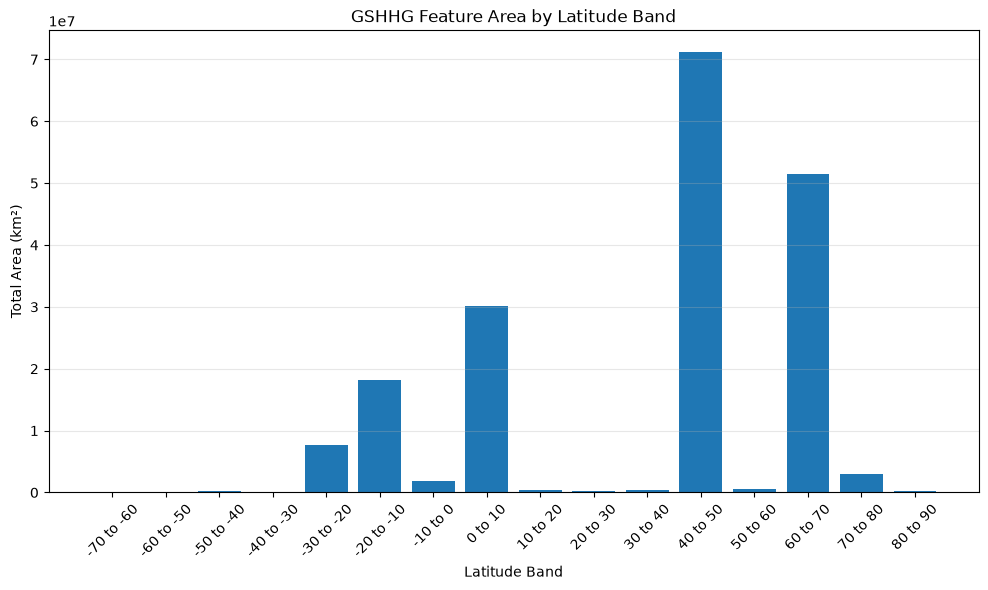

In [43]:
plt.figure(figsize=(12, 6))

plt.bar(
    latitude_area["latitude_band"].astype(str),
    latitude_area["total_area_km2"]
)

plt.xlabel("Latitude Band")
plt.ylabel("Total Area (km²)")
plt.title("GSHHG Feature Area by Latitude Band")

plt.xticks(rotation=45)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [44]:
geographic_complexity = (
    gdf_geo
    .groupby(
        ["lat_bin", "lon_bin"],
        observed=True
    )
    .agg(
        features=("id", "count"),
        total_vertices=("vertex_count", "sum"),
        mean_vertices=("vertex_count", "mean"),
    )
    .reset_index()
)

geographic_complexity.head()

,lat_bin,lon_bin,features,total_vertices,mean_vertices
0,"(-70.0, -60.0]","(-100.0, -90.0]",1,8,8.000000
1,"(-60.0, -50.0]","(-80.0, -70.0]",952,7417,7.790966
2,"(-60.0, -50.0]","(-70.0, -60.0]",210,2772,13.200000
3,"(-60.0, -50.0]","(-60.0, -50.0]",92,1005,10.923913
4,"(-60.0, -50.0]","(-40.0, -30.0]",11,250,22.727273


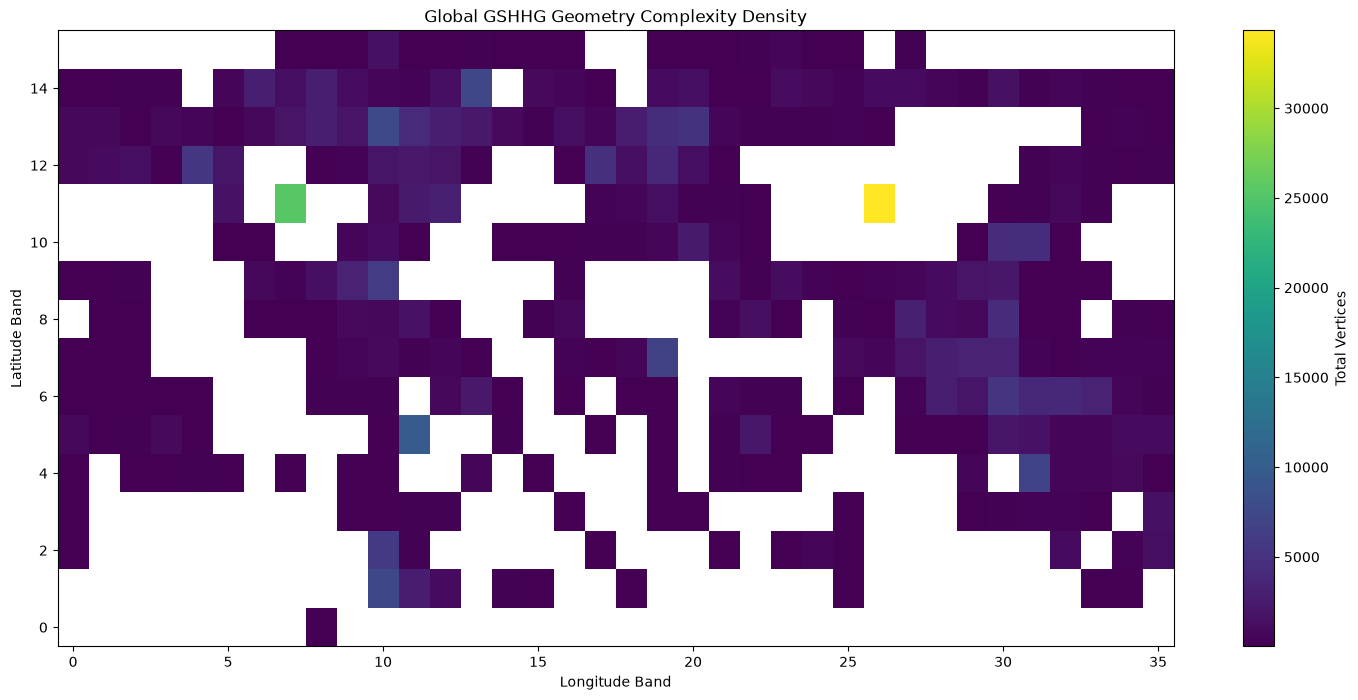

In [45]:
vertex_density_grid = geographic_complexity.pivot(
    index="lat_bin",
    columns="lon_bin",
    values="total_vertices"
)

plt.figure(figsize=(18, 8))

plt.imshow(
    vertex_density_grid,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Total Vertices"
)

plt.xlabel("Longitude Band")
plt.ylabel("Latitude Band")
plt.title("Global GSHHG Geometry Complexity Density")

plt.show()

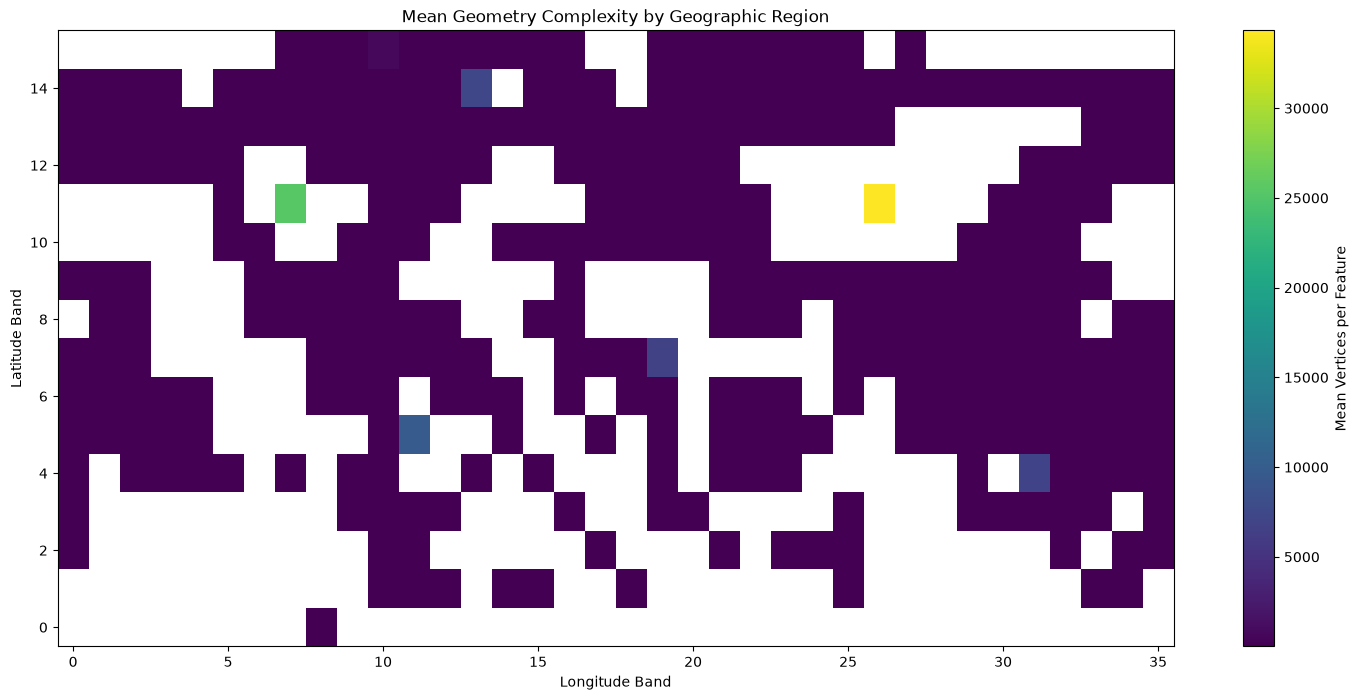

In [46]:
mean_complexity_grid = geographic_complexity.pivot(
    index="lat_bin",
    columns="lon_bin",
    values="mean_vertices"
)

plt.figure(figsize=(18, 8))

plt.imshow(
    mean_complexity_grid,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Mean Vertices per Feature"
)

plt.xlabel("Longitude Band")
plt.ylabel("Latitude Band")
plt.title("Mean Geometry Complexity by Geographic Region")

plt.show()

In [47]:
top_complex_regions = (
    geographic_complexity
    .sort_values(
        "total_vertices",
        ascending=False
    )
    .head(25)
)

top_complex_regions

,lat_bin,lon_bin,features,total_vertices,mean_vertices
205,"(40.0, 50.0]","(80.0, 90.0]",1,34332,34332.000000
195,"(40.0, 50.0]","(-110.0, -100.0]",1,25378,25378.000000
62,"(-20.0, -10.0]","(-70.0, -60.0]",1,9904,9904.000000
243,"(60.0, 70.0]","(-80.0, -70.0]",514,7620,14.824903
1,"(-60.0, -50.0]","(-80.0, -70.0]",952,7417,7.790966
275,"(70.0, 80.0]","(-50.0, -40.0]",1,7279,7279.000000
51,"(-30.0, -20.0]","(130.0, 140.0]",1,6844,6844.000000
118,"(0.0, 10.0]","(10.0, 20.0]",1,6675,6675.000000
161,"(20.0, 30.0]","(-80.0, -70.0]",839,6014,7.168057
11,"(-50.0, -40.0]","(-80.0, -70.0]",691,5811,8.409551


In [48]:
top_feature_regions = (
    geographic_complexity
    .sort_values(
        "features",
        ascending=False
    )
    .head(25)
)

top_feature_regions

,lat_bin,lon_bin,features,total_vertices,mean_vertices
253,"(60.0, 70.0]","(20.0, 30.0]",1049,5071,4.834128
1,"(-60.0, -50.0]","(-80.0, -70.0]",952,7417,7.790966
161,"(20.0, 30.0]","(-80.0, -70.0]",839,6014,7.168057
252,"(60.0, 70.0]","(10.0, 20.0]",754,4437,5.884615
191,"(30.0, 40.0]","(120.0, 130.0]",754,4420,5.862069
244,"(60.0, 70.0]","(-70.0, -60.0]",731,4144,5.668947
11,"(-50.0, -40.0]","(-80.0, -70.0]",691,5811,8.409551
225,"(50.0, 60.0]","(10.0, 20.0]",676,3869,5.723373
160,"(20.0, 30.0]","(-90.0, -80.0]",655,3356,5.123664
214,"(50.0, 60.0]","(-140.0, -130.0]",571,5396,9.450088


In [49]:
gdf_geo["large_longitude_extent"] = (
    gdf_geo["lon_span_deg"] >= 20
)

gdf_geo["large_latitude_extent"] = (
    gdf_geo["lat_span_deg"] >= 10
)

print(
    "Features spanning >= 20° longitude:",
    gdf_geo["large_longitude_extent"].sum()
)

print(
    "Features spanning >= 10° latitude:",
    gdf_geo["large_latitude_extent"].sum()
)

Features spanning >= 20° longitude: 8
Features spanning >= 10° latitude: 11


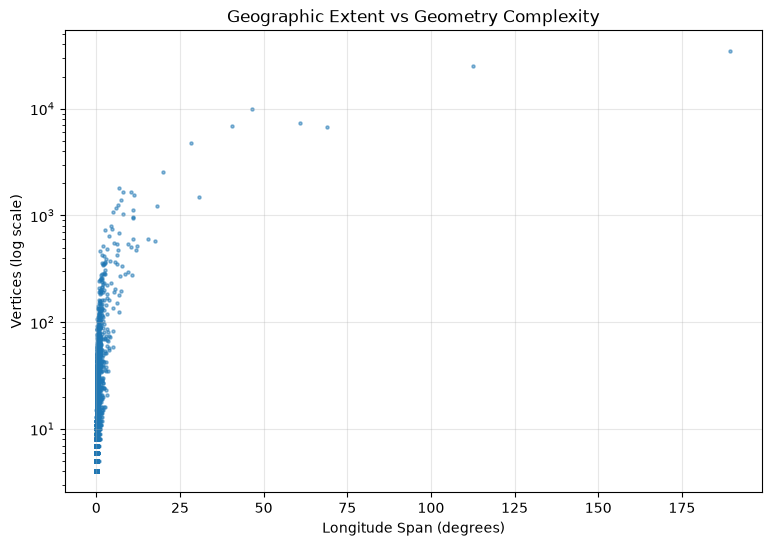

In [50]:
plt.figure(figsize=(9, 6))

plt.scatter(
    gdf_geo["lon_span_deg"],
    gdf_geo["vertex_count"],
    s=5,
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("Longitude Span (degrees)")
plt.ylabel("Vertices (log scale)")
plt.title("Geographic Extent vs Geometry Complexity")

plt.grid(True, alpha=0.3)

plt.show()

In [51]:
global_grid = []

for lat in range(-90, 90, 10):
    for lon in range(-180, 180, 10):

        global_grid.append({
            "min_lon": lon,
            "max_lon": lon + 10,
            "min_lat": lat,
            "max_lat": lat + 10,
            "geometry": box(
                lon,
                lat,
                lon + 10,
                lat + 10
            )
        })

global_grid = gpd.GeoDataFrame(
    global_grid,
    geometry="geometry",
    crs=gdf_geo.crs
)

global_grid.head()

,min_lon,max_lon,min_lat,max_lat,geometry
0,-180,-170,-90,-80,"POLYGON ((-170 -90, -170 -80, -180 -80, -180 -..."
1,-170,-160,-90,-80,"POLYGON ((-160 -90, -160 -80, -170 -80, -170 -..."
2,-160,-150,-90,-80,"POLYGON ((-150 -90, -150 -80, -160 -80, -160 -..."
3,-150,-140,-90,-80,"POLYGON ((-140 -90, -140 -80, -150 -80, -150 -..."
4,-140,-130,-90,-80,"POLYGON ((-130 -90, -130 -80, -140 -80, -140 -..."


In [52]:
feature_points = gdf_geo[
    ["id", "geometry"]
].copy()

feature_points["geometry"] = (
    feature_points.geometry.centroid
)

feature_points = gpd.GeoDataFrame(
    feature_points,
    geometry="geometry",
    crs=gdf_geo.crs
)

grid_feature_counts = gpd.sjoin(
    feature_points,
    global_grid,
    predicate="within",
    how="left"
)

grid_feature_counts.head()

C:\Users\devesh\AppData\Local\Temp\ipykernel_10436\1263277236.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  feature_points.geometry.centroid


,id,geometry,index_right,min_lon,max_lon,min_lat,max_lat
0,0-E,POINT (81.85626 48.45354),494,80,90,40,50
1,0-W,POINT (-175.84274 66.48022),540,-180,-170,60,70
2,1,POINT (17.66818 6.90124),343,10,20,0,10
3,2,POINT (-105.96083 49.58628),475,-110,-100,40,50
4,3,POINT (-60.73418 -14.77929),263,-70,-60,-20,-10


In [53]:
grid_counts = (
    grid_feature_counts
    .groupby("index_right")
    .size()
    .rename("feature_count")
)

global_grid["feature_count"] = (
    grid_counts
    .reindex(global_grid.index)
    .fillna(0)
)

global_grid.head()

,min_lon,max_lon,min_lat,max_lat,geometry,feature_count
0,-180,-170,-90,-80,"POLYGON ((-170 -90, -170 -80, -180 -80, -180 -...",0.0
1,-170,-160,-90,-80,"POLYGON ((-160 -90, -160 -80, -170 -80, -170 -...",0.0
2,-160,-150,-90,-80,"POLYGON ((-150 -90, -150 -80, -160 -80, -160 -...",0.0
3,-150,-140,-90,-80,"POLYGON ((-140 -90, -140 -80, -150 -80, -150 -...",0.0
4,-140,-130,-90,-80,"POLYGON ((-130 -90, -130 -80, -140 -80, -140 -...",0.0


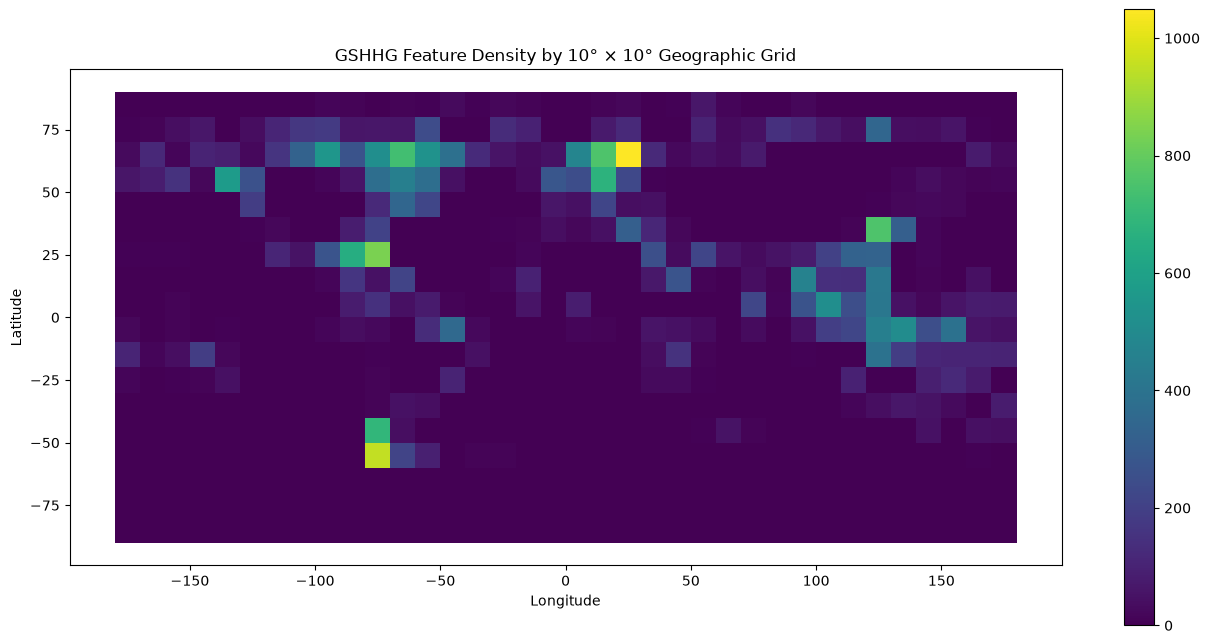

In [54]:
fig, ax = plt.subplots(figsize=(16, 8))

global_grid.plot(
    ax=ax,
    column="feature_count",
    legend=True,
    linewidth=0.2
)

ax.set_title(
    "GSHHG Feature Density by 10° × 10° Geographic Grid"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [55]:
geographic_report = pd.DataFrame({
    "metric": [
        "Feature count",
        "Minimum longitude",
        "Maximum longitude",
        "Minimum latitude",
        "Maximum latitude",
        "Features north of 60°N",
        "Features south of 60°S",
        "Features near dateline",
        "Features reaching north polar region",
        "Features reaching south polar region",
        "Features spanning >= 20° longitude",
        "Features spanning >= 10° latitude",
        "Total vertices",
        "Total area (km²)",
    ],
    "value": [
        len(gdf_geo),
        gdf_geo["min_lon"].min(),
        gdf_geo["max_lon"].max(),
        gdf_geo["min_lat"].min(),
        gdf_geo["max_lat"].max(),
        (gdf_geo["centroid_lat"] >= 60).sum(),
        (gdf_geo["centroid_lat"] <= -60).sum(),
        len(dateline_features),
        len(north_polar),
        len(south_polar),
        gdf_geo["large_longitude_extent"].sum(),
        gdf_geo["large_latitude_extent"].sum(),
        gdf_geo["vertex_count"].sum(),
        gdf_geo["area"].sum(),
    ]
})

geographic_report

,metric,value
0,Feature count,3.283000e+04
1,Minimum longitude,-1.800000e+02
2,Maximum longitude,1.800000e+02
3,Minimum latitude,-6.891981e+01
4,Maximum latitude,8.363339e+01
5,Features north of 60°N,9.493000e+03
6,Features south of 60°S,1.000000e+00
7,Features near dateline,6.330000e+02
8,Features reaching north polar region,2.510000e+02
9,Features reaching south polar region,0.000000e+00
